
DATASET LOADED SUCCESSFULLY

  Condition      Time  SleepFactor         ATP        ROS  SeverityScore  \
0   Healthy  0.000000     1.000000  100.000000  10.000000       0.100000   
1   Healthy  0.000052     0.999958  100.000026  10.000016       0.099996   
2   Healthy  0.000104     0.999917  100.000052  10.000031       0.099992   
3   Healthy  0.000246     0.999803  100.000123  10.000074       0.099981   
4   Healthy  0.000388     0.999690  100.000194  10.000116       0.099970   

  BrainState ConnectivityStatus  
0    Healthy             Stable  
1    Healthy             Stable  
2    Healthy             Stable  
3    Healthy             Stable  
4    Healthy             Stable  

DATASET SHAPE: (1189, 8)


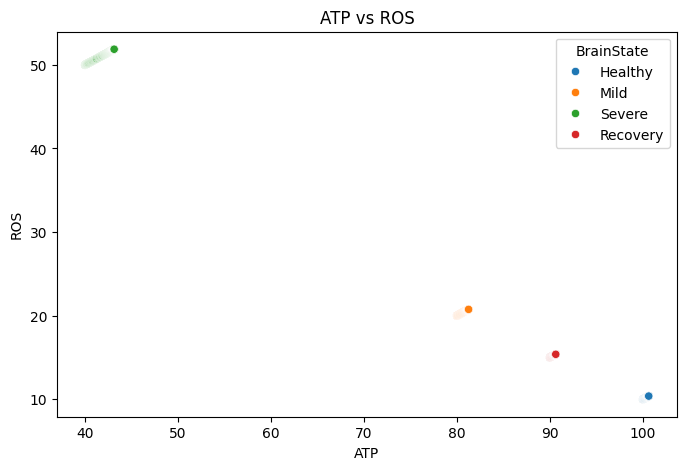

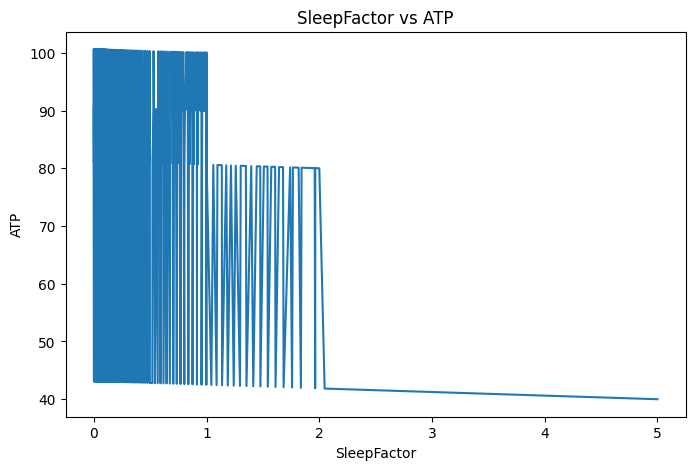

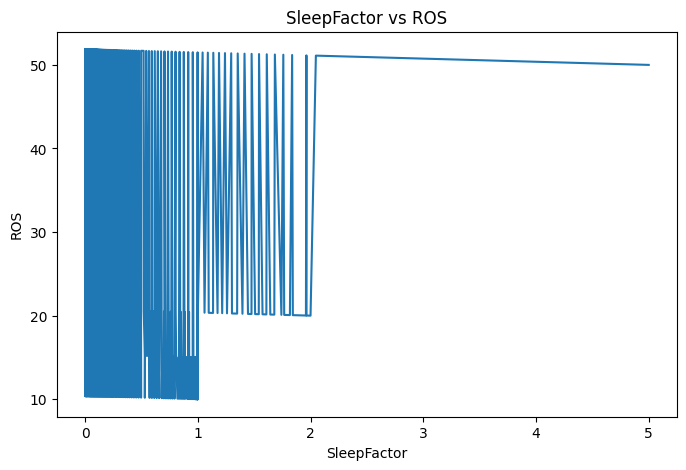


================ MODEL RESULTS ================


Logistic Regression
----------------------------------------
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        65
           2       1.00      1.00      1.00        54
           3       1.00      1.00      1.00        65

    accuracy                           1.00       238
   macro avg       1.00      1.00      1.00       238
weighted avg       1.00      1.00      1.00       238


Decision Tree
----------------------------------------
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       1.00      1.00      1.00        65
           2       1.00      1.00      1.00        54
           3       1.00      1.00      1.00        65

    accuracy                           1.00       238
   macro avg       1.00      1.00      1.00


Enter choice (1 or 2):  2



========== GENERAL USER MODE ==========



How many hours have you not slept? :  34



Predicted Biological Parameters

Predicted ATP: 30
Predicted ROS: 65
Predicted SleepFactor: 6

FINAL AI PREDICTION RESULTS

Predicted Brain State: Severe
Connectivity Status: Damaged Connectivity
Severity Score: 13.0
Risk Level: Critical Risk

Biological Interpretation:
High oxidative stress and reduced ATP indicate severe sleep deprivation and damaged neural connectivity.

FINAL RESULTS SAVED SUCCESSFULLY


In [1]:
# Sleep Deprivation AI Prediction System — FINAL HYBRID CODE

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# =========================================================
# LOAD DATASET
# =========================================================

dataset_path = r"C:\Users\HP\Documents\Sleep_Deprivation_Project\acm.csv"

# =========================================================
# VCELL INTEGRATION MODULE (SIMULATION INTERFACE)
# =========================================================

print("\n==============================================")
print("VCELL SIMULATION INTERFACE INITIALIZED")
print("==============================================")

# NeuroSleep Digital Twin Platform
# VCell → Machine Learning Integration Layer
#
# This module represents the interface between
# biological simulations generated in VCell and
# the AI prediction engine developed in Python.
#
# VCell simulates:
# - ATP (Cellular Energy)
# - ROS (Oxidative Stress)
# - SleepFactor (Sleep Deprivation Severity)
#
# Workflow:
#
# Sleep Deprivation
#        ↓
# VCell Biological Simulation
#        ↓
# ATP / ROS Generation
#        ↓
# CSV Dataset Export
#        ↓
# Machine Learning Training
#        ↓
# Brain State Prediction
#        ↓
# Connectivity Analysis
#
# Current Mode:
# Offline Simulation Integration
#
# Future Mode:
# Real-Time VCell → AI Pipeline

vcell_connected = True

if vcell_connected:

    print("Status  : Connected")

    print("Platform: VCell Biological Simulation Engine")

    print("Source  : ATP / ROS Simulation Dataset")

    print("Mode    : Offline Integration")

    print("Bridge  : VCell → CSV → Machine Learning")

    print("Result  : Biological Parameters Imported")

else:

    print("Status  : Disconnected")

    print("Source  : VCell Not Available")

print("==============================================\n")

df = pd.read_csv(dataset_path)

print("\nDATASET LOADED SUCCESSFULLY\n")

print(df.head())

# =========================================================
# DATA CLEANING
# =========================================================

df.drop_duplicates(inplace=True)

print("\nDATASET SHAPE:", df.shape)

# =========================================================
# LABEL ENCODING
# =========================================================

brain_encoder = LabelEncoder()

df["BrainState_Label"] = brain_encoder.fit_transform(df["BrainState"])

# =========================================================
# FEATURES & TARGET
# =========================================================

X = df[["SleepFactor", "ATP", "ROS", "SeverityScore"]]

y = df["BrainState_Label"]

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="ATP", y="ROS", hue="BrainState")
plt.title("ATP vs ROS")
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(data=df, x="SleepFactor", y="ATP")
plt.title("SleepFactor vs ATP")
plt.show()

plt.figure(figsize=(8,5))
sns.lineplot(data=df, x="SleepFactor", y="ROS")
plt.title("SleepFactor vs ROS")
plt.show()

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "SVM": SVC(),

    "KNN": KNeighborsClassifier()

}

best_accuracy = 0
best_model = None
best_model_name = ""

print("\n================ MODEL RESULTS ================\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("-" * 40)

    print("Accuracy:", accuracy)

    print(classification_report(y_test, y_pred))

    if accuracy > best_accuracy:

        best_accuracy = accuracy
        best_model = model
        best_model_name = name

# =========================================================
# SAVE BEST MODEL
# =========================================================

joblib.dump(best_model, "best_sleep_model.pkl")

print("\nBEST MODEL:", best_model_name)

print("BEST ACCURACY:", best_accuracy)

# =========================================================
# HYBRID PREDICTION SYSTEM
# =========================================================

print("\n==============================================")
print("SLEEP DEPRIVATION AI PREDICTION SYSTEM")
print("==============================================")

print("\nChoose Prediction Mode:\n")

print("1. Clinical Mode")
print("2. General User Mode")

mode = input("\nEnter choice (1 or 2): ")

# =========================================================
# GENERAL USER MODE
# =========================================================

if mode == "2":

    print("\n========== GENERAL USER MODE ==========\n")

    hours = float(input("How many hours have you not slept? : "))

    # SIMPLE BIOLOGICAL ESTIMATION

    if hours <= 2:

        ATP = 95
        ROS = 12
        SleepFactor = 1

    elif hours <= 6:

        ATP = 80
        ROS = 20
        SleepFactor = 2

    elif hours <= 10:

        ATP = 65
        ROS = 35
        SleepFactor = 3

    elif hours <= 14:

        ATP = 45
        ROS = 50
        SleepFactor = 5

    else:

        ATP = 30
        ROS = 65
        SleepFactor = 6

    SeverityScore = (ROS / ATP) * SleepFactor

    print("\nPredicted Biological Parameters\n")

    print("Predicted ATP:", ATP)

    print("Predicted ROS:", ROS)

    print("Predicted SleepFactor:", SleepFactor)

# =========================================================
# CLINICAL MODE
# =========================================================

else:

    print("\n========== CLINICAL MODE ==========\n")

    SleepFactor = float(input("Enter SleepFactor: "))

    ATP = float(input("Enter ATP value: "))

    ROS = float(input("Enter ROS value: "))

    SeverityScore = (ROS / ATP) * SleepFactor

# =========================================================
# MODEL PREDICTION
# =========================================================

input_data = pd.DataFrame([[
    SleepFactor,
    ATP,
    ROS,
    SeverityScore
]], columns=[
    "SleepFactor",
    "ATP",
    "ROS",
    "SeverityScore"
])

input_scaled = scaler.transform(input_data)

prediction = best_model.predict(input_scaled)

brain_state = brain_encoder.inverse_transform(prediction)[0]

# =========================================================
# RISK CLASSIFICATION
# =========================================================

if SeverityScore <= 0.5:

    risk = "Low Risk"

elif SeverityScore <= 2:

    risk = "Moderate Risk"

elif SeverityScore <= 5:

    risk = "High Risk"

else:

    risk = "Critical Risk"

# =========================================================
# CONNECTIVITY STATUS
# =========================================================

if brain_state == "Healthy":

    connectivity = "Stable Connectivity"

elif brain_state == "Mild":

    connectivity = "Slightly Weak Connectivity"

elif brain_state == "Recovery":

    connectivity = "Partially Restored Connectivity"

else:

    connectivity = "Damaged Connectivity"

# =========================================================
# BIOLOGICAL INTERPRETATION
# =========================================================

if brain_state == "Severe":

    interpretation = (
        "High oxidative stress and reduced ATP "
        "indicate severe sleep deprivation and "
        "damaged neural connectivity."
    )

elif brain_state == "Mild":

    interpretation = (
        "Moderate ATP reduction and elevated ROS "
        "suggest early-stage neural stress."
    )

elif brain_state == "Recovery":

    interpretation = (
        "Improved ATP and reduced ROS indicate "
        "partial neural recovery."
    )

else:

    interpretation = (
        "Normal ATP and ROS levels indicate "
        "stable neural communication."
    )

# =========================================================
# FINAL OUTPUT
# =========================================================

print("\n==============================================")
print("FINAL AI PREDICTION RESULTS")
print("==============================================")

print("\nPredicted Brain State:", brain_state)

print("Connectivity Status:", connectivity)

print("Severity Score:", round(SeverityScore, 3))

print("Risk Level:", risk)

print("\nBiological Interpretation:")

print(interpretation)

# =========================================================
# SAVE RESULTS
# =========================================================

with open("final_results.txt", "w") as f:

    f.write("Sleep Deprivation AI Prediction Results\n\n")

    f.write(f"Best Model: {best_model_name}\n")

    f.write(f"Best Accuracy: {best_accuracy}\n\n")

    f.write(f"Predicted Brain State: {brain_state}\n")

    f.write(f"Connectivity Status: {connectivity}\n")

    f.write(f"Severity Score: {SeverityScore}\n")

    f.write(f"Risk Level: {risk}\n\n")

    f.write("Interpretation:\n")

    f.write(interpretation)

print("\nFINAL RESULTS SAVED SUCCESSFULLY")

